# Warehouse Operations Simulation — Results Analysis

Exploratory analysis of the Monte Carlo results produced by
`run_simulation.py` (500 simulated peak-demand days per scenario).
Three labor/automation plans are compared on the same demand stream:
baseline staffing, AMR-assisted picking, and a peak-aligned shift.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

OUT = Path("../outputs") if Path("../outputs").exists() else Path("outputs")

summary = pd.read_csv(OUT / "scenario_summary.csv").set_index("scenario")
reps = pd.read_csv(OUT / "replication_results.csv")
cycle_sample = pd.read_csv(OUT / "cycle_times_sample.csv")
with open(OUT / "scenario_results.json") as f:
    results_meta = json.load(f)

print(f"Replications per scenario: {results_meta['replications_per_scenario']}")
headline = summary[[
    "same_day_shipped_mean", "same_day_ship_rate_mean", "cycle_mean_min_mean",
    "cycle_p95_min_mean", "peak_utilization_mean",
]].round(3)
headline

Replications per scenario: 500


,same_day_shipped_mean,same_day_ship_rate_mean,cycle_mean_min_mean,cycle_p95_min_mean,peak_utilization_mean
scenario,,,,,
baseline,616.956,0.978,75.920,133.425,0.951
amr_automation,631.222,1.000,45.987,76.640,0.817
shift_policy,631.080,1.000,68.441,98.088,0.951


## Labor utilization by stage

Utilization is busy staff-minutes divided by scheduled staff-minutes.
The 85% line is the planning ceiling: above it, queues (and missed
same-day ships) grow quickly on peak days.

,receiving,picking,packing,shipping
scenario,,,,
baseline,0.526,0.951,0.789,0.526
amr_automation,0.526,0.815,0.789,0.526
shift_policy,0.526,0.951,0.789,0.526


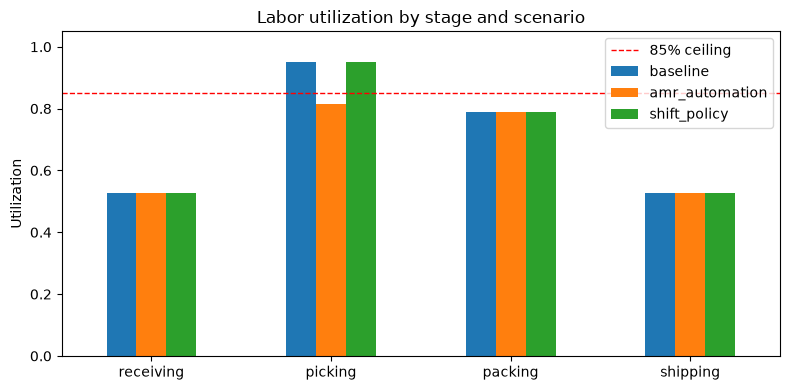

In [2]:
stages = ["receiving", "picking", "packing", "shipping"]
util = summary[[f"util_{s}_mean" for s in stages]]
util.columns = stages
display(util.round(3))

ax = util.T.plot.bar(figsize=(8, 4), rot=0)
ax.axhline(0.85, color="red", linestyle="--", linewidth=1, label="85% ceiling")
ax.set_ylabel("Utilization")
ax.set_ylim(0, 1.05)
ax.set_title("Labor utilization by stage and scenario")
ax.legend()
plt.tight_layout()
plt.show()

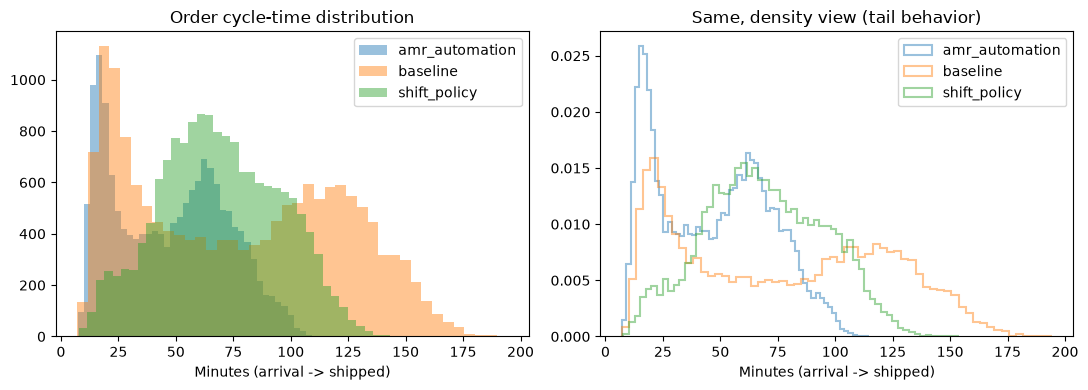

,count,mean,std,min,50%,90%,95%,99%,max
scenario,,,,,,,,,
amr_automation,15847.0,47.0,24.7,7.3,47.9,80.0,86.9,98.3,114.7
baseline,15847.0,76.9,45.1,7.1,76.3,136.8,148.4,163.5,194.2
shift_policy,15847.0,69.2,26.0,7.8,67.9,104.7,111.4,124.0,154.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, group in cycle_sample.groupby("scenario"):
    axes[0].hist(group["cycle_time_min"], bins=40, alpha=0.45, label=name)
    axes[1].hist(group["cycle_time_min"], bins=60, alpha=0.45, label=name,
                 density=True, histtype="step", linewidth=1.5)
axes[0].set_title("Order cycle-time distribution")
axes[0].set_xlabel("Minutes (arrival -> shipped)")
axes[1].set_title("Same, density view (tail behavior)")
axes[1].set_xlabel("Minutes (arrival -> shipped)")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

cycle_sample.groupby("scenario")["cycle_time_min"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]).round(1)

## Reading the results

- **Baseline** meets the same-day target on most days but runs picking
  at ~95% utilization on peak days - no headroom for volume growth,
  absenteeism, or equipment downtime, and ~2% of orders slip past the
  18:00 cutoff.
- **AMR-assisted picking** removes the bottleneck: cycle time falls
  ~39% and picking utilization drops below the 85% ceiling with a
  smaller crew (7 vs 10 pickers).
- **Peak-aligned shift** spends the *same* picker labor-hours but
  times them to the demand peak. Average utilization is unchanged by
  construction (identical busy and scheduled minutes); the gain shows
  up where it matters - P95 cycle time (-27%) and same-day ships.
  Re-timing labor is the zero-capex lever; automation is the
  structural one.